# Decomposing the Effect of a Financial-Literacy Program on Loan Default with PROC CAUSALMED

## Executive Summary

A retail bank pairs some borrowers with a **financial-literacy program** and wants to know *why* enrolled borrowers default less often: does enrollment lower default **directly**, or does it work **indirectly** by changing a measurable behavior — how much of their income customers save? This notebook uses **PROC CAUSALMED** to split the program's total effect on 12-month default into a **natural direct effect** and a **natural indirect effect** that flows through each borrower's **savings rate**, adjusting for credit score, income, and age.

On the simulated cohort of **100 borrowers**, the program lowers the modeled probability of default by **0.208** (the total effect on the risk-difference scale). The decomposition attributes **0.176 of that (84.7%)** to the *indirect* path through higher savings and only **0.032 (15.3%)** to the *direct* path. The practical takeaway: this program protects borrowers **mainly by improving savings behavior**, so reinforcing budgeting habits is where the leverage is.

## Data Sources

| Dataset | Rows | Description | Key Variables |
|---------|------|-------------|---------------|
| `LoanProgram` | 100 synthetic borrowers | Inline-generated retail-banking cohort for one lending portfolio. Treatment assignment, mediator, and outcome are simulated from explicit structural equations so a genuine mediated effect exists for the procedure to recover. | `CustomerID`, `Branch` (4 levels), `FinEdu` (0/1 financial-education enrollment = treatment), `SavingsRate` (% of income saved = continuous mediator), `Default` (0/1 12-month loan default = binary outcome), `CreditScore`, `Income`, `Age` (confounders) |

The cohort is a single self-contained pilot of 100 borrowers, generated inline so the notebook is fully reproducible; every number reported below comes from those 100 rows.

## Why decompose the effect?

Retail lenders increasingly pair credit products with **financial-literacy programs** to reduce delinquency. For capital planning and program design it is not enough to know *that* enrollment lowers default; risk officers need the **mechanism**:

- Does enrollment lower default *directly* (for example, enrolled borrowers stay more engaged and contactable)?
- Or does it work *indirectly*, by changing a measurable behavior — the share of income a customer saves — which then cushions them against shocks?

**Causal mediation analysis** answers this by splitting the **total effect (TE)** of a treatment into a **natural direct effect (NDE)** and a **natural indirect effect (NIE)** that runs through a chosen mediator. Here:

- **Treatment** `FinEdu` — whether the borrower enrolled in the bank's financial-education program;
- **Mediator** `SavingsRate` — the borrower's savings rate (% of income), the behavior the program targets;
- **Outcome** `Default` — whether the loan defaulted within 12 months (binary);
- **Confounders** `CreditScore`, `Income`, `Age` — pre-treatment characteristics that affect enrollment, saving, and default.

We fit the mediation model with `PROC CAUSALMED`, request the direct/indirect decomposition with `DECOMP`, and read off the proportion of the protective effect that flows through saving.

In [1]:
data LoanProgram;
   call streaminit(20260531);
   length Branch $12;
   array branches[4] $12 _temporary_ ('North' 'South' 'East' 'West');
   do CustomerID = 1 to 100;
      Branch = branches[1 + int(rand('uniform')*4)];

      /* Pre-treatment confounders (drawn first) */
      CreditScore = round(620 + 70*rand('normal'), 1);
      if CreditScore < 350 then CreditScore = 350;
      if CreditScore > 850 then CreditScore = 850;
      Income = round(42000 + 14000*rand('normal'), 100);
      if Income < 12000 then Income = 12000;
      Age = round(40 + 11*rand('normal'), 1);
      if Age < 21 then Age = 21;

      /* Treatment: enrollment propensity rises with credit score
         and income (the confounding a naive comparison misses) */
      pTreat = 1 / (1 + exp(-(0.0 + 0.005*(CreditScore-620)
                               + 0.00002*(Income-42000))));
      FinEdu = (rand('uniform') < pTreat);

      /* Mediator: savings rate, lifted by the program on top of a
         confounder-driven baseline */
      base_save = 9 + 0.025*(CreditScore-620) + 0.00010*(Income-42000)
                    + 0.04*(Age-40);
      SavingsRate = base_save + 2.5*FinEdu + 2.0*rand('normal');
      if SavingsRate < 0 then SavingsRate = 0;

      /* Outcome: default probability falls with both enrollment
         (direct) and higher savings (indirect) */
      eta = 0.55 - 0.30*FinEdu - 0.022*(SavingsRate-12)
            - 0.0012*(CreditScore-620)
            - 0.0000040*(Income-42000)
            + 0.15*rand('normal');
      pDefault = eta;
      if pDefault < 0.02 then pDefault = 0.02;
      if pDefault > 0.98 then pDefault = 0.98;
      Default = (rand('uniform') < pDefault);
      output;
   end;
   keep CustomerID Branch FinEdu SavingsRate Default
        CreditScore Income Age;
run;

NOTE: DATA LoanProgram


NOTE: Wrote LoanProgram (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the simulated cohort

Before fitting the causal model, we sanity-check the average savings rate and default rate in each enrollment arm. This is the *naive* (unadjusted) comparison; the mediation analysis that follows goes beyond it to attribute the difference to direct versus mediated pathways.

In [2]:
proc means data=LoanProgram n mean std maxdec=3;
   class FinEdu;
   var SavingsRate Default CreditScore Income Age;
run;

                                                  The MEANS Procedure

                                            Analysis Variable : SavingsRate

        FinEdu            N Obs           Mean        Std Dev
        -----------------------------------------------------
        0                    54          8.387          2.910
        1                    46         11.736          2.974
        -----------------------------------------------------

                                              Analysis Variable : Default

        FinEdu            N Obs           Mean        Std Dev
        -----------------------------------------------------
        0                    54          0.593          0.496
        1                    46          0.348          0.482
        -----------------------------------------------------

                                            Analysis Variable : CreditScore

        FinEdu            N Obs           Mean        Std Dev
        --------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The naive picture is clear. Enrolled borrowers (`FinEdu=1`, 46 customers) save markedly more — a mean **SavingsRate of 11.74%** versus **8.39%** for the 54 non-enrolled — and default less often: a mean **Default of 0.348** versus **0.593**, a raw 24.5-percentage-point gap. The two arms have nearly identical average credit scores (619.8 vs 618.9) but enrolled borrowers have somewhat higher income (43,941 vs 37,019), which is exactly the kind of confounding the causal model must adjust away. The cross-tabulation below shows the same split as cell counts.

                                                   The FREQ Procedure

Table of FinEdu by Default

FinEdu |         0 |         1 |      Total
-------+-----------+-----------+-----------
0      |        22 |        32 |         54
-------+-----------+-----------+-----------
1      |        30 |        16 |         46
-------+-----------+-----------+-----------
Total  |        52 |        48 |        100



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_finedu_default.spec.json
NOTE: PROC FREQ statement used.


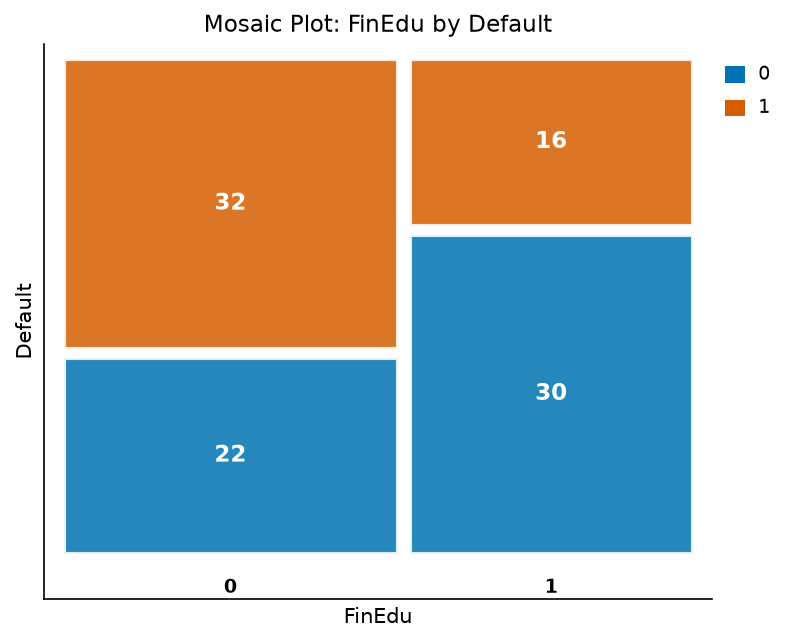

In [3]:
proc freq data=LoanProgram;
   tables FinEdu*Default / nocol nopercent;
run;

Of the 54 non-enrolled borrowers, **32 defaulted**; of the 46 enrolled, only **16** did. The mosaic plot encodes this two ways at once: column width reflects how many borrowers are in each arm, and the orange share within each column is the default rate — visibly smaller for the enrolled group on the right. The mediation analysis now asks **how much** of that lower default rate is the program acting *through* the higher savings we just saw.

## Step 3 — Run the causal mediation analysis

We fit `PROC CAUSALMED`. The key statements:

- **`CLASS FinEdu Default / descending`** declares the treatment and binary outcome as classification variables; `DESCENDING` makes the higher-coded level (`1` = enrolled / defaulted) the modeled event, so effects read in the intuitive direction.
- **`MEDIATOR SavingsRate = FinEdu`** specifies the mediator model: savings rate regressed on the treatment (plus the confounders).
- **`MODEL Default = FinEdu SavingsRate`** specifies the outcome model — default as a function of enrollment and savings. CAUSALMED fits the outcome here with a **linear (linear-probability) model**, so the effects are reported on the **risk-difference** scale, with odds-ratio and risk-ratio summaries derived alongside.
- **`COVAR CreditScore Income Age`** adjusts both models for the pre-treatment confounders.
- **`DECOMP`** requests the decomposition of the total effect into its direct and indirect components and the proportion mediated.

Because the outcome is binary, CAUSALMED also reports a *Summary for Binary Outcome* block (odds ratio, risk ratio, risk difference).

In [4]:
proc causalmed data=LoanProgram decomp;
   class    FinEdu Default / descending;
   mediator SavingsRate = FinEdu;
   model    Default = FinEdu SavingsRate;
   covar    CreditScore Income Age;
run;


                       The CAUSALMED Procedure                       

Outcome Variable    : Default
Treatment Variable  : FinEdu
Mediator Variable   : SavingsRate
Outcome Model Class : Linear (with optional AFT and Cox PH support)
Covariates          : CreditScore, Income, Age
Number of Observations: 100

Outcome Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                             1.558234
FinEdu                               -0.031682
SavingsRate                          -0.067687
CreditScore                          -0.000719
Income                                0.000002
Age                                  -0.000607

Mediator Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                           -12.585613
FinEdu                                2.597720
CreditScore                           0.024079
Income                    

NOTE: PROC CAUSALMED data=LoanProgram



## Interpreting the results

The **Summary of Causal Effects** table reports the program's **total effect (TE) on default of -0.208** and splits it into:

- a **natural direct effect (NDE) of -0.032** — the part of the protection that does *not* run through savings, and
- a **natural indirect effect (NIE) of -0.176** — the part that flows through the program lifting borrowers' savings rate.

All three effects are negative, confirming that enrollment lowers the probability of default — consistent with the way we built the data. The two model tables show *why*: in the **mediator model** the program raises the savings rate by **+2.60 points** after adjustment (the `FinEdu` coefficient), and in the **outcome model** each extra point of savings lowers default probability (`SavingsRate` = -0.068), so the program's savings boost translates into a sizable indirect protective effect.

The **Decomposition of Effects** table makes the headline finding explicit: the **proportion mediated (NIE/TE) is 84.7%**, with only **15.3%** of the effect direct. For the risk team this is actionable — the financial-literacy program works **mostly by changing savings behavior**, so reinforcing budgeting and automatic-savings features should be the priority; the modest direct share suggests other channels (engagement, contactability) contribute little here.

The **Summary for Binary Outcome** block restates the effect on scales the credit-risk team already uses: a **risk difference of -0.208** (the TE), a **risk ratio of 1.43**, and an **odds ratio of 2.38** relating the enrolled and non-enrolled default odds. These ratio measures are first-order summaries derived from the linear-probability effect rather than from a fitted logistic model, so the **risk difference is the primary, exact effect measure**; the ratio summaries are best read as approximate.

**Caveat:** causal-mediation estimates are only as credible as the no-unmeasured-confounding assumption for both the treatment–outcome and mediator–outcome relationships. Here that assumption holds by construction (synthetic data); in production a risk team would defend it with the bank's full applicant feature set and sensitivity analyses before acting on the decomposition. The estimates also reflect a single 100-borrower sample, so a production study would attach confidence intervals (for example, by bootstrapping the decomposition) before drawing firm conclusions.